In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load your data
volume_path = r"C:\Users\yasiru\Desktop\fyp-3d-ct\image-processing\data_volumes\dataset\train\train_1387\train_1387_a\train_1387_a_2.nii.gz"
mask_path = r"C:\Users\yasiru\Desktop\fyp-3d-ct\image-processing\segmentations\segmentations\train_1387_a_2.nii.gz"

ct = nib.load(volume_path).get_fdata().astype(np.float32)
ct = np.clip(ct, -1024, 3071)

gt_mask = nib.load(mask_path).get_fdata()
if gt_mask.ndim == 4:
    gt_mask = gt_mask[0]
gt_mask = gt_mask > 0

print("CT shape:", ct.shape)
print("GT shape:", gt_mask.shape)

CT shape: (512, 512, 461)
GT shape: (512, 512, 461)


Selected slice: 333
GT pixels on slice: 269


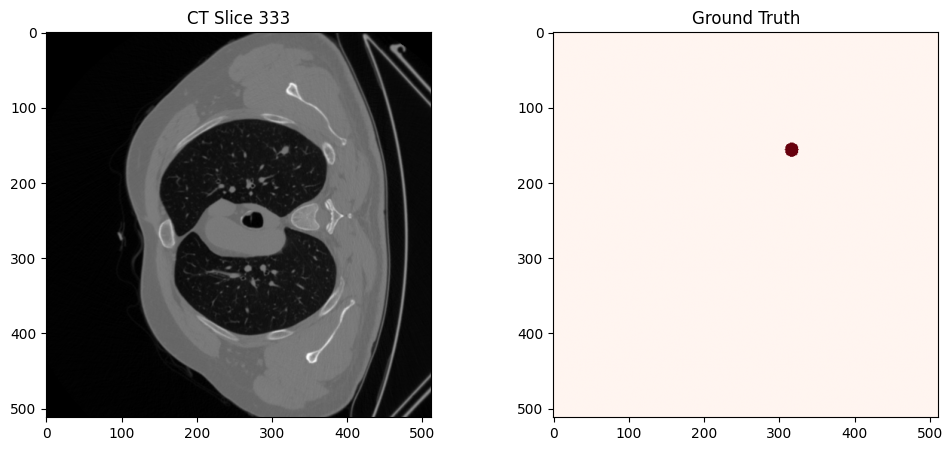

In [2]:
# Select slice with most GT pixels
gt_slices = np.sum(gt_mask, axis=(0, 1))
slice_idx = int(np.argmax(gt_slices))

print("Selected slice:", slice_idx)
print("GT pixels on slice:", int(gt_mask[:, :, slice_idx].sum()))

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(ct[:, :, slice_idx], cmap="gray")
ax[0].set_title(f"CT Slice {slice_idx}")
ax[1].imshow(gt_mask[:, :, slice_idx], cmap="Reds")
ax[1].set_title("Ground Truth")
plt.show()

In [3]:
from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label

# Step 1: HU threshold
lung_candidate = (ct >= -900) & (ct <= -200)

# Step 2: Remove border air
mask_clear = np.zeros_like(lung_candidate, dtype=bool)
for k in range(ct.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])

# Step 3: Keep largest components
def keep_largest_components(binary_mask, n=2):
    labeled, num = label(binary_mask, return_num=True, connectivity=1)
    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = np.argsort(sizes)[-n:]
    return np.isin(labeled, largest)

lungs_only = keep_largest_components(mask_clear, n=2)

# Step 4: Morphological cleanup
structure = ndimage.generate_binary_structure(3, 2)
lungs_final = ndimage.binary_closing(lungs_only, structure=structure, iterations=2)
lungs_final = ndimage.binary_fill_holes(lungs_final)

# Step 5: Apply mask to CT
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000

print("Lung mask voxels:", int(lungs_final.sum()))

Lung mask voxels: 12544165
